In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)

y = pd.Series(data.target, name='diagnosis')

print(f'Veri seti boyutu : {X.shape}  (satır x sütun)')
print(f'Malignant (0)    : {(y==0).sum()} örnek')
print(f'Benign (1)       : {(y==1).sum()} örnek')
print(f'Toplam           : {len(y)} örnek')

Veri seti boyutu : (569, 30)  (satır x sütun)
Malignant (0)    : 212 örnek
Benign (1)       : 357 örnek
Toplam           : 569 örnek


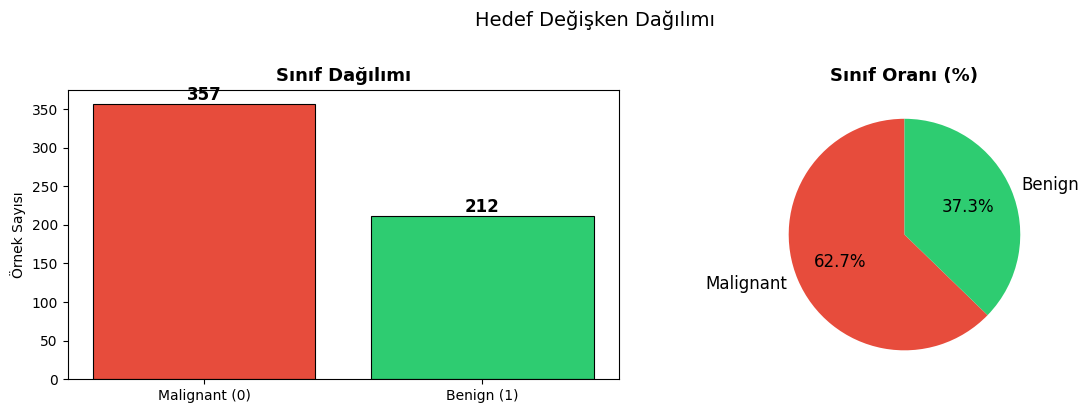

Malignant: 212 (%37.3)
Benign   : 357 (%62.7)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sinif_sayilari = y.value_counts()
renkler = ['#e74c3c', '#2ecc71']
axes[0].bar(['Malignant (0)', 'Benign (1)'], sinif_sayilari.values,
             color=renkler, edgecolor='black', linewidth=0.8)
axes[0].set_title('Sınıf Dağılımı', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Örnek Sayısı')

for i, v in enumerate(sinif_sayilari.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(sinif_sayilari.values, labels=['Malignant', 'Benign'],
            colors=renkler, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Sınıf Oranı (%)', fontsize=13, fontweight='bold')

plt.suptitle('Hedef Değişken Dağılımı', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Malignant: {sinif_sayilari[0]} (%{sinif_sayilari[0]/len(y)*100:.1f})')
print(f'Benign   : {sinif_sayilari[1]} (%{sinif_sayilari[1]/len(y)*100:.1f})')

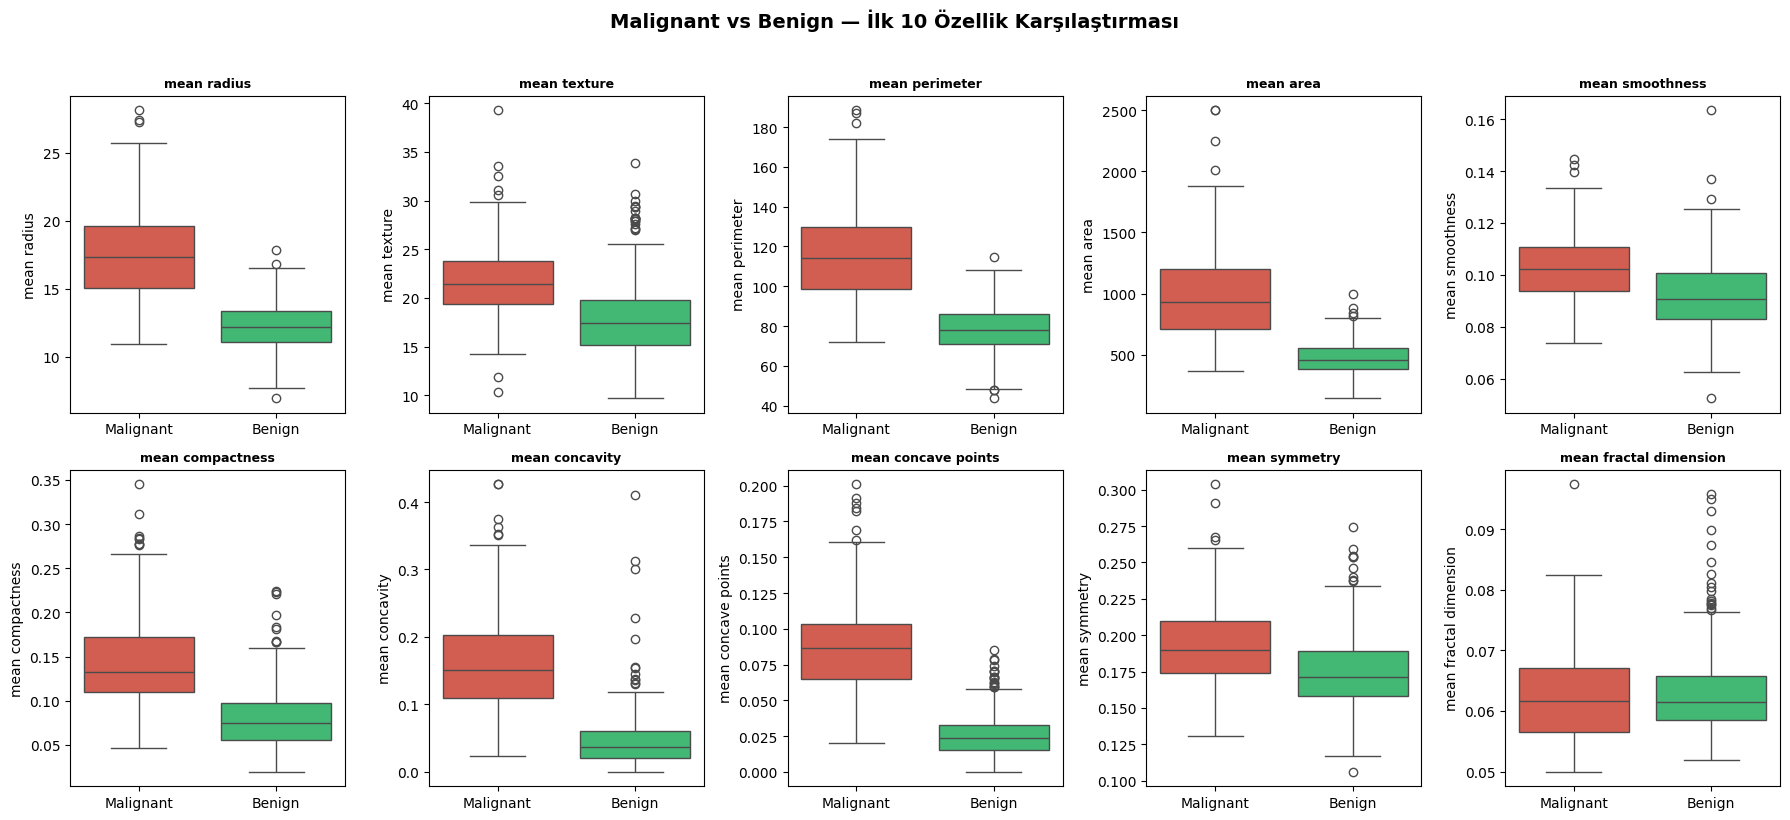

In [6]:
df_gorsel = X.iloc[:, :10].copy()
df_gorsel['diagnosis'] = y.map({0: 'Malignant', 1: 'Benign'})

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(X.columns[:10]):
    sns.boxplot(data=df_gorsel, x='diagnosis', y=col, ax=axes[i],
                palette={'Malignant': '#e74c3c', 'Benign': '#2ecc71'})
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Malignant vs Benign — İlk 10 Özellik Karşılaştırması',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

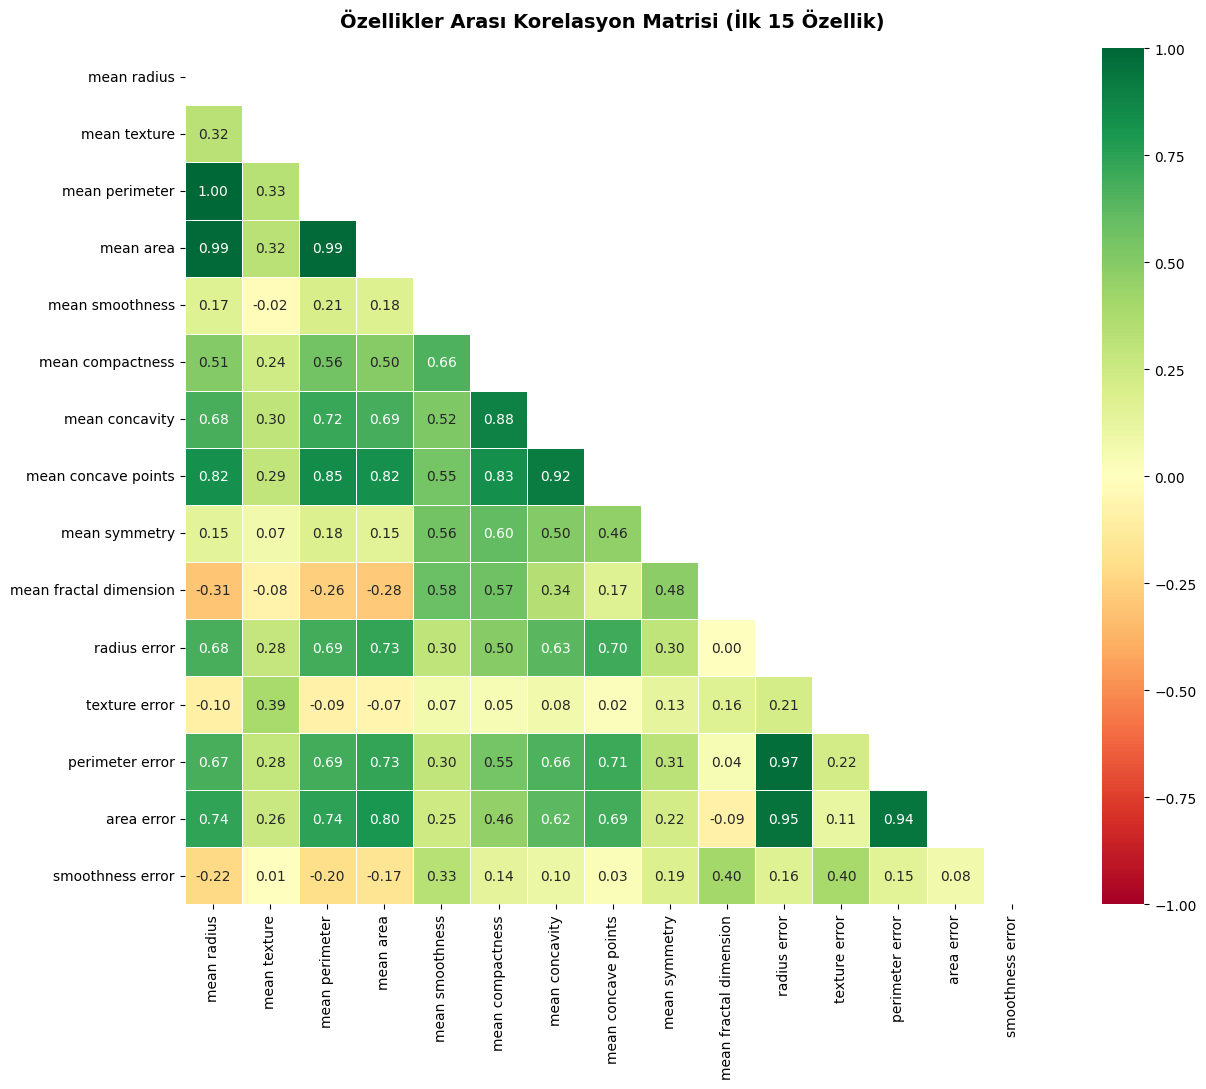

In [7]:
plt.figure(figsize=(14, 11))

korelasyon_matrisi = X.iloc[:, :15].corr()

mask = np.triu(np.ones_like(korelasyon_matrisi, dtype=bool))

sns.heatmap(
    korelasyon_matrisi,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    vmin=-1, vmax=1,
    square=True
)
plt.title('Özellikler Arası Korelasyon Matrisi (İlk 15 Özellik)',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Eğitim seti boyutu : {X_train.shape}  ({len(X_train)} örnek)')
print(f'Test seti boyutu   : {X_test.shape}   ({len(X_test)} örnek)')
print()
print('Eğitim setinde sınıf dağılımı:')
print(y_train.value_counts().to_string())
print()
print('Test setinde sınıf dağılımı:')
print(y_test.value_counts().to_string())

Eğitim seti boyutu : (455, 30)  (455 örnek)
Test seti boyutu   : (114, 30)   (114 örnek)

Eğitim setinde sınıf dağılımı:
diagnosis
1    285
0    170

Test setinde sınıf dağılımı:
diagnosis
1    72
0    42


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(f'Ölçeklendirme sonrası eğitim verisi ortalaması: {X_train_scaled.mean():.6f}  (0\'a yakın olmalı)')
print(f'Ölçeklendirme sonrası eğitim verisi std       : {X_train_scaled.std():.6f}   (1\'e yakın olmalı)')
print('Ölçeklendirme tamamlandı!')

Ölçeklendirme sonrası eğitim verisi ortalaması: -0.000000  (0'a yakın olmalı)
Ölçeklendirme sonrası eğitim verisi std       : 1.000000   (1'e yakın olmalı)
Ölçeklendirme tamamlandı!


In [10]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0
)

lr_model.fit(X_train_scaled, y_train)

lr_tahmin = lr_model.predict(X_test_scaled)

print('Logistic Regression eğitimi tamamlandı!')
print(f'İlk 10 tahmin: {lr_tahmin[:10]}')
print(f'Gerçek değer : {y_test.values[:10]}')

Logistic Regression eğitimi tamamlandı!
İlk 10 tahmin: [0 1 0 1 0 1 1 0 0 0]
Gerçek değer : [0 1 0 1 0 1 1 0 0 0]


In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
rf_tahmin = rf_model.predict(X_test_scaled)

print('Random Forest eğitimi tamamlandı!')
print(f'Ağaç sayısı: {rf_model.n_estimators}')

Random Forest eğitimi tamamlandı!
Ağaç sayısı: 100


In [12]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
svm_tahmin = svm_model.predict(X_test_scaled)

print('SVM eğitimi tamamlandı!')

SVM eğitimi tamamlandı!


In [13]:
modeller = {
    'Logistic Regression': (lr_model, lr_tahmin),
    'Random Forest'       : (rf_model, rf_tahmin),
    'SVM (RBF)'           : (svm_model, svm_tahmin),
}

sonuclar = []

print(f'{"Model":<22} {"Accuracy":>10} {"Precision":>10} {"Recall":>8} {"F1":>8}')

for model_adi, (model, tahmin) in modeller.items():
    acc  = accuracy_score(y_test, tahmin)
    prec = precision_score(y_test, tahmin)
    rec  = recall_score(y_test, tahmin)
    f1   = f1_score(y_test, tahmin)

    sonuclar.append({
        'Model'     : model_adi,
        'Accuracy'  : acc,
        'Precision' : prec,
        'Recall'    : rec,
        'F1-Score'  : f1
    })

    print(f'{model_adi:<22} {acc:>10.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f}')


sonuc_df = pd.DataFrame(sonuclar).set_index('Model')

en_iyi = sonuc_df['F1-Score'].idxmax()
print(f'\nEn İyi Model (F1-Score): {en_iyi}')

Model                    Accuracy  Precision   Recall       F1
Logistic Regression        0.9825     0.9861   0.9861   0.9861
Random Forest              0.9561     0.9589   0.9722   0.9655
SVM (RBF)                  0.9825     0.9861   0.9861   0.9861

En İyi Model (F1-Score): Logistic Regression


In [14]:
sonuc_df.style.format('{:.4f}').background_gradient(cmap='YlOrRd', axis=None)

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.9825,0.9861,0.9861,0.9861
Random Forest,0.9561,0.9589,0.9722,0.9655
SVM (RBF),0.9825,0.9861,0.9861,0.9861


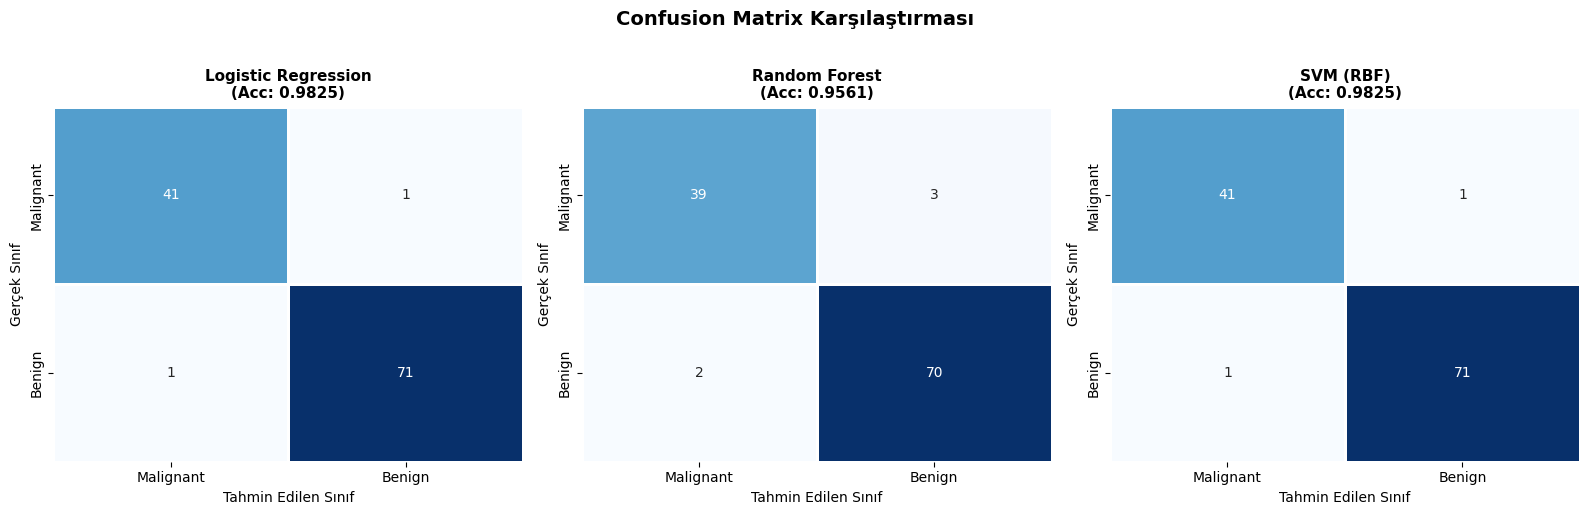

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (model_adi, (model, tahmin)) in enumerate(modeller.items()):
    cm = confusion_matrix(y_test, tahmin)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i],
        xticklabels=['Malignant', 'Benign'],
        yticklabels=['Malignant', 'Benign'],
        cbar=False,
        linewidths=1
    )
    axes[i].set_title(f'{model_adi}\n(Acc: {accuracy_score(y_test,tahmin):.4f})',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Tahmin Edilen Sınıf', fontsize=10)
    axes[i].set_ylabel('Gerçek Sınıf', fontsize=10)

    tn, fp, fn, tp = cm.ravel()

plt.suptitle('Confusion Matrix Karşılaştırması', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

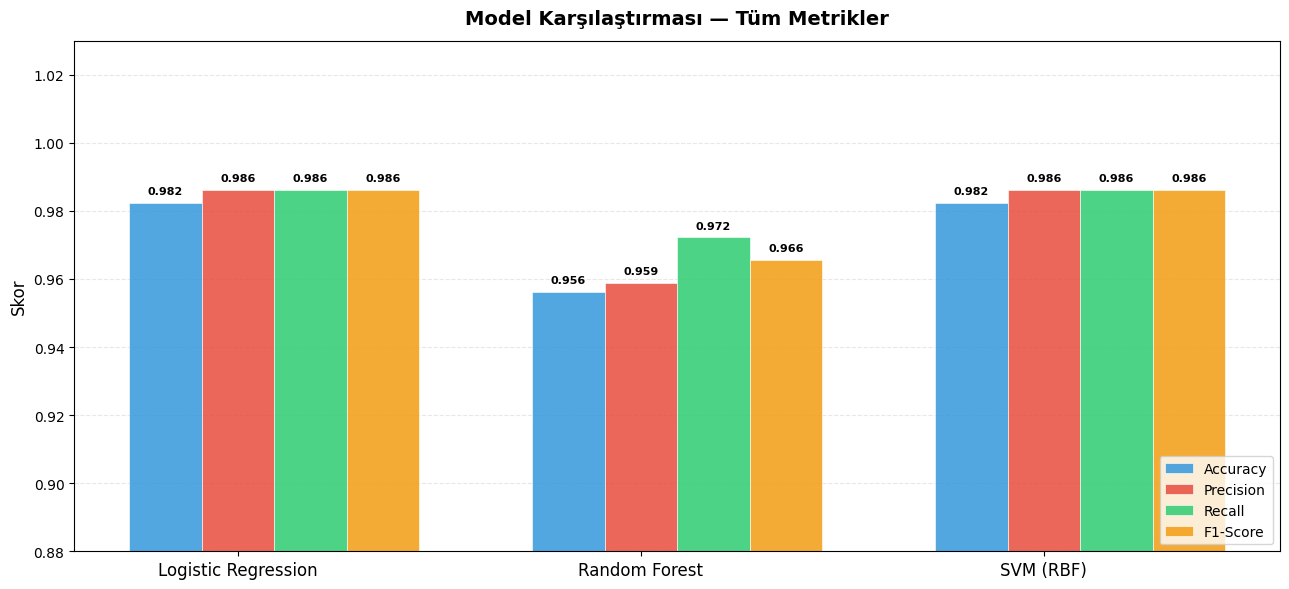

In [18]:
metrik_listesi = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
renkler = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

x = np.arange(len(sonuc_df.index))
genislik = 0.18

fig, ax = plt.subplots(figsize=(13, 6))

for j, (metrik, renk) in enumerate(zip(metrik_listesi, renkler)):
    degerler = sonuc_df[metrik].values

    barlar = ax.bar(
        x + j * genislik - 1.5 * genislik + genislik/2,
        degerler,
        width=genislik,
        label=metrik,
        color=renk,
        alpha=0.85,
        edgecolor='white',
        linewidth=0.5
    )

    for bar, val in zip(barlar, degerler):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(sonuc_df.index, fontsize=12)
ax.set_ylim(0.88, 1.03)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Model Karşılaştırması — Tüm Metrikler', fontsize=14, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.yaxis.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

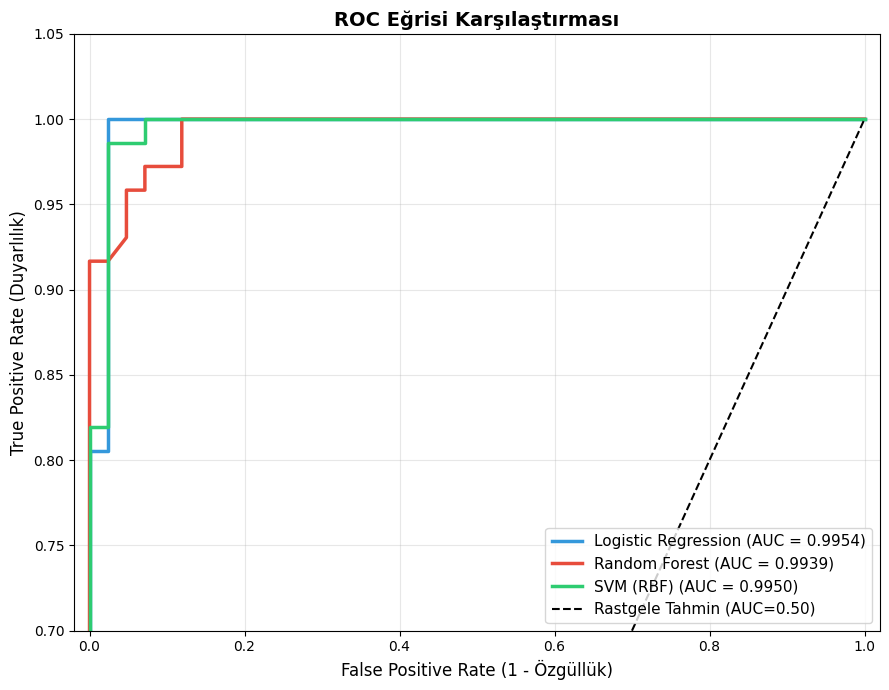

In [21]:
renkler_roc = ['#3498db', '#e74c3c', '#2ecc71']

plt.figure(figsize=(9, 7))

for i, (model_adi, (model, tahmin)) in enumerate(modeller.items()):
    olasilik = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, olasilik)

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=renkler_roc[i], lw=2.5,
             label=f'{model_adi} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Rastgele Tahmin (AUC=0.50)')

plt.xlim([-0.02, 1.02])
plt.ylim([0.70, 1.05])
plt.xlabel('False Positive Rate (1 - Özgüllük)', fontsize=12)
plt.ylabel('True Positive Rate (Duyarlılık)', fontsize=12)
plt.title('ROC Eğrisi Karşılaştırması', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

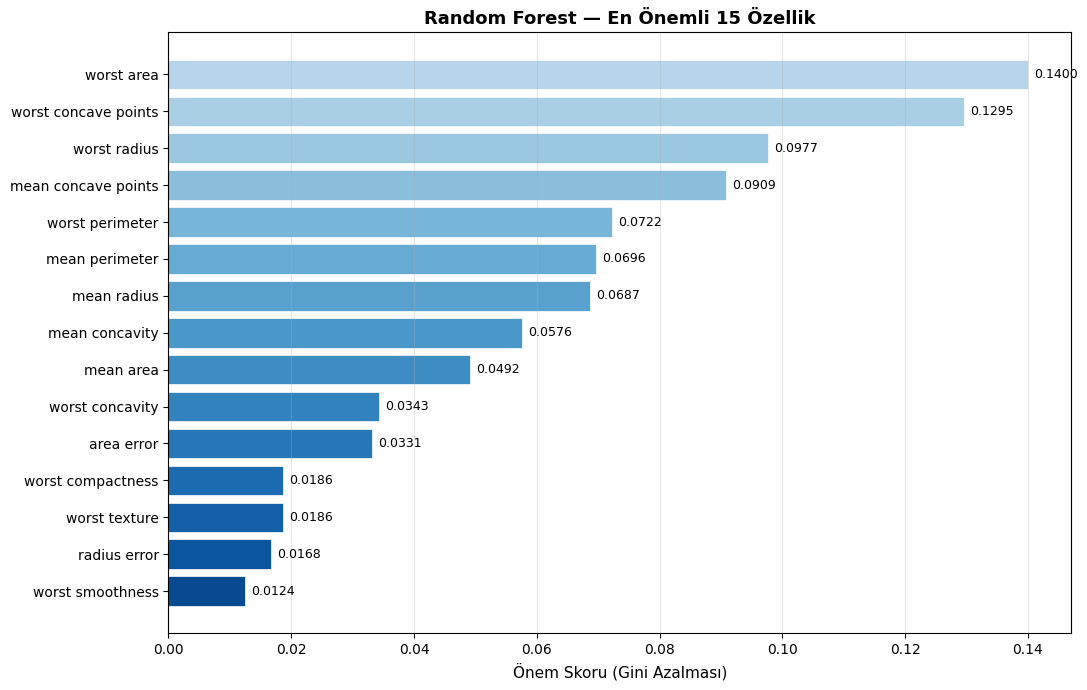

In [23]:
onem_skorlari = pd.Series(
    rf_model.feature_importances_,
    index=data.feature_names
).sort_values(ascending=False)

plt.figure(figsize=(11, 7))

renkler_onem = plt.cm.Blues(np.linspace(0.3, 0.9, 15))[::-1]

bars = plt.barh(
    range(15),
    onem_skorlari.values[:15][::-1],
    color=renkler_onem,
    edgecolor='white',
    linewidth=0.5
)

for bar, val in zip(bars, onem_skorlari.values[:15][::-1]):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.yticks(range(15), onem_skorlari.index[:15][::-1], fontsize=10)
plt.xlabel('Önem Skoru (Gini Azalması)', fontsize=11)
plt.title('Random Forest — En Önemli 15 Özellik', fontsize=13, fontweight='bold')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
print('MEME KANSERİ SINIFLANDIRMA — ÖZET SONUÇLAR'.center(63))
print(f'{"Model":<22} {"Accuracy":>9} {"Precision":>9} {"Recall":>7} {"F1":>7}')
for _, row in sonuc_df.iterrows():
    print(f'{row.name:<22} {row["Accuracy"]:>9.4f} {row["Precision"]:>9.4f} {row["Recall"]:>7.4f} {row["F1-Score"]:>7.4f}')

en_iyi_f1 = sonuc_df['F1-Score'].idxmax()
en_iyi_recall = sonuc_df['Recall'].idxmax()
print('\nAnaliz tamamlandı!')

           MEME KANSERİ SINIFLANDIRMA — ÖZET SONUÇLAR          
Model                   Accuracy Precision  Recall      F1
Logistic Regression       0.9825    0.9861  0.9861  0.9861
Random Forest             0.9561    0.9589  0.9722  0.9655
SVM (RBF)                 0.9825    0.9861  0.9861  0.9861

Analiz tamamlandı!
